In [2]:
#pentru a putea folosi TPU, am sters JAX peuntru a preveni conflictele de dependente
# si am instalat versiunea de TF 2.18.0 optimizata pt  si driverele libtpu de la Google
!export PATH="${HOME}/.local/bin:${PATH}" && uv pip uninstall --system jax jaxlib
!export PATH="${HOME}/.local/bin:${PATH}" && uv pip install --system tensorflow-tpu==2.18.0 --find-links https://storage.googleapis.com/libtpu-tf-releases/index.html

Using Python 3.12.13 environment at: /usr/local
Uninstalled 2 packages in 210ms
 - jax==0.9.2
 - jaxlib==0.9.2
Using Python 3.12.13 environment at: /usr/local
Resolved 38 packages in 406ms                                        
Prepared 6 packages in 4.80s                                             
Uninstalled 5 packages in 249ms
Installed 6 packages in 4.02s                               
 - libtpu==0.0.17
 + libtpu==2.18.0
 - ml-dtypes==0.5.4
 + ml-dtypes==0.4.1
 - numpy==2.4.3
 + numpy==2.0.2
 - protobuf==7.34.0
 + protobuf==5.29.6
 - tensorboard==2.20.0
 + tensorboard==2.18.0
 + tensorflow-tpu==2.18.0


In [3]:
import tensorflow as tf
from kaggle_datasets import KaggleDatasets
import numpy as np
import keras

print("Tensorflow version " + tf.__version__)
print("kaggle version" +  keras.__version__)

E0000 00:00:1776320628.516573      12 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:230


Tensorflow version 2.18.0
kaggle version3.13.2


In [4]:
#initializare TPU
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local') 
    print('Running on TPU ', tpu.master())
    
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    
except ValueError as e:
    print("TPU connection failed:", e)
    tpu = None
    strategy = tf.distribute.get_strategy()

print("REPLICAS: ", strategy.num_replicas_in_sync)

Running on TPU  
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


I0000 00:00:1776320680.969190      12 service.cc:148] XLA service 0x56ceb0547110 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776320680.969225      12 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1776320680.969228      12 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1776320680.969231      12 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1776320680.969233      12 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1776320680.969237      12 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1776320680.969239      12 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1776320680.969241      12 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1776320680.969243      12 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

In [7]:
# === Preprocesare și Augmentare Date ===
#
# Datasetul FER2013 conține imagini faciale de 48×48 px în grayscale, organizate
# în 7 clase de emoții: Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral.
#
# Split-ul folosit:
#   - Train:      80% din directorul train_dir  (~22.968 imagini)
#   - Validare:   20% din directorul train_dir  (~5.742 imagini)
#   - Test:       directorul test_dir           (~7.178 imagini)
#
# Augmentare aplicată pe setul de antrenare:
#   - Rescaling [0, 1]
#   - Rotație aleatorie ±10%
#   - Translație ±10% (H și W)
#   - Zoom aleatoriu ±10%
#   - Flip orizontal
#   - Contrast aleatoriu ±20%
#
# Validarea și testul primesc exclusiv rescaling, fără augmentare.
# Batch size: 512.
# Pipeline optimizat cu shuffle(5000) + prefetch(AUTOTUNE).
import tensorflow as tf
from tensorflow.keras import layers

train_dir = '/kaggle/input/datasets/prilia/fer2013pluscleanedaugmballanced1/train'
test_dir = '/kaggle/input/datasets/prilia/fer2013pluscleanedaugmballanced1/test'

img_size = 48
batch_size = 512  # better for TPU v3-8
num_classes = 7
epoci = 100        # more epochs

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.20, subset="training", seed=123,
    image_size=(img_size, img_size), batch_size=batch_size,
    color_mode="grayscale", label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.20, subset="validation", seed=123,
    image_size=(img_size, img_size), batch_size=batch_size,
    color_mode="grayscale", label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(img_size, img_size), batch_size=batch_size,
    color_mode="grayscale", label_mode="categorical", shuffle=False
)

data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.2)
])

rescaling_only = tf.keras.Sequential([
    layers.Rescaling(1./255)
])

train_ds = (train_ds
    .unbatch()
    .batch(batch_size, drop_remainder=True)
    .shuffle(5000, reshuffle_each_iteration=True)
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

val_ds = (val_ds
    .unbatch()
    .batch(batch_size, drop_remainder=True)
    .map(lambda x, y: (rescaling_only(x, training=False), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

test_ds = (test_ds
    .unbatch()
    .batch(batch_size, drop_remainder=True)
    .map(lambda x, y: (rescaling_only(x, training=False), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

Found 23251 files belonging to 7 classes.
Using 18601 files for training.
Found 23251 files belonging to 7 classes.
Using 4650 files for validation.
Found 5772 files belonging to 7 classes.


Generăm variante augmentate corect...


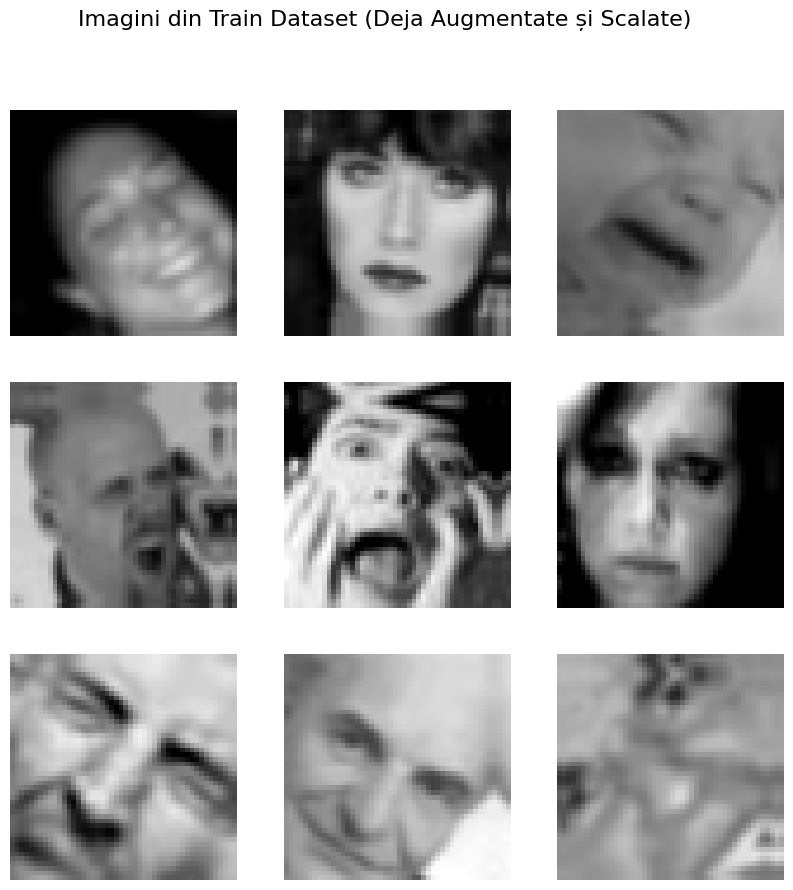

In [8]:
# === Vizualizare Imagini Augmentate ===
#
# Extragem primul batch din train_ds și afișăm 9 imagini într-un grid 3×3.
# Imaginile sunt deja procesate de pipeline:
#   - Rescalate în intervalul [0, 1]
#   - Augmentate aleatoriu (rotație, zoom, flip, translație, contrast)
#
# Scopul: validare vizuală că pipeline-ul funcționează corect
# înainte de a începe antrenarea modelului.
import matplotlib.pyplot as plt
import numpy as np

print("Generăm variante augmentate corect...")

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
        plt.axis("off")
    plt.suptitle("Imagini din Train Dataset (Deja Augmentate și Scalate)", fontsize=16)
    plt.show()

In [9]:
#pt fer-2013 aratam etichetele fiecarei emotii adica un numar 
clase = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
class_labels = {name: i for i, name in enumerate(clase)}

print("Etichete (valabile pentru Antrenament, Validare și Test):")
print(class_labels)

print(f"\nVerificare clase detectate: {len(clase)} emoții")
for i, emotion in enumerate(clase):
    print(f"Index {i} -> {emotion}")

Etichete (valabile pentru Antrenament, Validare și Test):
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Verificare clase detectate: 7 emoții
Index 0 -> angry
Index 1 -> disgust
Index 2 -> fear
Index 3 -> happy
Index 4 -> neutral
Index 5 -> sad
Index 6 -> surprise


In [10]:
# === Arhitectură V-CNN (Dogaru & Dogaru, 2023) ===
# Implementare adaptată pentru FER2013 (48×48 grayscale, 7 clase emoții).
# Structură: 3 blocuri convoluționale cu [64, 128, 64] filtre, fiecare bloc conținând
# straturi Conv2D + ReLU, BatchNormalization, MaxPooling și Dropout(0.5).
# Capul de clasificare: GlobalAveragePooling2D → Dense(7, softmax).
# Compilat cu Adam + categorical crossentropy. Instanțiat în scopul strategiei TPU.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, Activation, BatchNormalization, 
                                     MaxPooling2D, Dropout, Flatten, 
                                     GlobalAveragePooling2D, Dense)

def create_v_cnn_model_fer(input_shape=(48, 48, 1), num_classes=7, 
                            flat=0, fil=[64, 128, 64], nl=[2, 1, 1], hid=[]):
    csize = 3
    stri = 2
    psiz = 4
    pad = 'same'
    drop1 = 0.5

    nfilmax = len(fil)
    model = Sequential()

    layer = 0
    if nl[layer] > 0:
        model.add(Conv2D(fil[layer], padding=pad, kernel_size=(csize, csize), input_shape=input_shape))
        model.add(Activation('relu'))
        for nonlin in range(1, nl[0]):
            model.add(Conv2D(fil[layer], padding=pad, kernel_size=(csize, csize)))
            model.add(Activation('relu'))
        model.add(Conv2D(fil[0], padding=pad, kernel_size=(csize, csize)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(psiz, psiz), strides=(stri, stri), padding=pad))
        model.add(Dropout(drop1))
    else:
        model.add(Conv2D(fil[0], padding=pad, kernel_size=(csize, csize), input_shape=input_shape))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(psiz, psiz), strides=(stri, stri), padding=pad))
        model.add(Dropout(drop1))

    for layer in range(1, nfilmax):
        for nonlin in range(nl[layer]):
            model.add(Conv2D(fil[layer], padding=pad, kernel_size=(csize, csize)))
            model.add(Activation('relu'))
        model.add(Conv2D(fil[layer], padding=pad, kernel_size=(csize, csize)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(psiz, psiz), strides=(stri, stri), padding=pad))
        model.add(Dropout(drop1))

    if flat == 1:
        model.add(Flatten())
    else:
        model.add(GlobalAveragePooling2D())

    if len(hid) > 0:
        for units in hid:
            model.add(Dense(units, activation='relu'))
            model.add(Dropout(drop1))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

with strategy.scope():
    model = create_v_cnn_model_fer(
        input_shape=(48, 48, 1),
        num_classes=7,
        flat=0,
        fil=[64, 128, 64],
        nl=[2, 2, 1],
        hid=[]
    )

model.summary()

/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776320730.365365      12 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 555,719 (2.12 MB)

 Trainable params: 555,207 (2.12 MB)

 Non-trainable params: 512 (2.00 KB)

In [11]:
# Callbacks: salvare best model (val_accuracy), early stopping (patience=20),
# reducere LR la platou (factor=0.5, patience=7, min_lr=1e-6).
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "vcnn_best_model_fer_augmented.keras",
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=20,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5, 
    patience=7, 
    min_lr=1e-6, 
    verbose=1
)


In [12]:
# === Antrenare Model ===
# Se lansează antrenarea pe TPU pentru maximum 100 epoci, cu validare la fiecare epocă.
# Callbacks active: checkpoint (best model), early stopping (patience=20), ReduceLROnPlateau.
# Timpul de antrenare este cronometrat pentru a fi raportat ulterior.
import time

print("Începem antrenamentul pe TPU...")

t_start_train = time.time()
istoric_antrenare = model.fit(
    train_ds,
    epochs=epoci,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping, lr_scheduler]
)
t_end_train = time.time()

Începem antrenamentul pe TPU...
Epoch 1/100


I0000 00:00:1776320744.219965      12 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:7202092608089010941
I0000 00:00:1776320744.491561    1355 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(1623699176520487612), session_name()


      7/Unknown 12s 20ms/step - accuracy: 0.1392 - loss: 2.5926

I0000 00:00:1776320754.494803    1355 tpu_compile_op_common.cc:245] Compilation of 1623699176520487612 with session name  took 10.003198021s and succeeded
I0000 00:00:1776320754.509454    1355 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(1623699176520487612), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_7202092608089010941", property.function_library_fingerprint = 8128151955887128015, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 4, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1776320754.509481    1355 tpu_compilation_cache_interface.cc:542] After adding entry for key 1623699176520487612 with 

     34/Unknown 13s 18ms/step - accuracy: 0.1794 - loss: 2.1613

...


Epoch 51: val_accuracy did not improve from 0.76432

Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.7969 - loss: 0.5427 - val_accuracy: 0.7617 - val_loss: 0.6398 - learning_rate: 2.5000e-04
Epoch 52/100
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7914 - loss: 0.5546
Epoch 52: val_accuracy did not improve from 0.76432
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8020 - loss: 0.5264 - val_accuracy: 0.7457 - val_loss: 0.6620 - learning_rate: 1.2500e-04
Epoch 53/100
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7969 - loss: 0.5298
Epoch 53: val_accuracy did not improve from 0.76432
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8037 - loss: 0.5256 - val_accuracy: 0.7502 - val_loss: 0.6579 - learning_rate: 1.2500e-04
Epoch 54/100


I0000 00:00:1776320932.134997   29463 tpu_compile_op_common.cc:108] TpuCompileOp was cancelled. Sleeping for 300 seconds to give time for TPUCompileOp to finished.


34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7966 - loss: 0.5424

I0000 00:00:1776320934.318256   29620 tpu_compile_op_common.cc:108] TpuCompileOp was cancelled. Sleeping for 300 seconds to give time for TPUCompileOp to finished.



Epoch 54: val_accuracy did not improve from 0.76432
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8035 - loss: 0.5288 - val_accuracy: 0.7435 - val_loss: 0.6861 - learning_rate: 1.2500e-04
Epoch 55/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8113 - loss: 0.5299
Epoch 55: val_accuracy did not improve from 0.76432
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8072 - loss: 0.5233 - val_accuracy: 0.7635 - val_loss: 0.6135 - learning_rate: 1.2500e-04
Epoch 56/100
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8029 - loss: 0.5087
Epoch 56: val_accuracy did not improve from 0.76432
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8051 - loss: 0.5205 - val_accuracy: 0.7606 - val_loss: 0.6418 - learning_rate: 1.2500e-04
Epoch 57/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7951 - loss: 0.5274
Epoch 57: val_accuracy did not improve from 0.76432
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8048 - loss: 0.5188 - val_accuracy: 0.7595 -

In [15]:
# === Evaluare Model Final ===
# Se încarcă cel mai bun model salvat de checkpoint și se evaluează pe test set.
# Se raportează: timpul total de antrenare (minute), numărul de parametri,
# acuratețea pe test și latența medie de inferență per imagine (ms).
import time
import tensorflow as tf
timp_total_minute = int(t_end_train - t_start_train) / 60
print('Training with  ',epoci,' epochs, lasted  ',timp_total_minute,' minutes')

model_salvat = tf.keras.models.load_model("vcnn_best_model_fer_augmented.keras")

print('Număr total de parametri:', model_salvat.count_params())

t1_eval = time.time()
score = model_salvat.evaluate(test_ds, verbose=0)
t2_eval = time.time()

print(f'Cea mai buna acuratete de test: {score[1] * 100}%')

numar_imagini_test=7178

timp_total_ms = (t2_eval - t1_eval) * 1000
latenta_per_imagine = timp_total_ms / numar_imagini_test

print(f'Latența la predicție (per imagine): {latenta_per_imagine:.4f} ms')


Training with   100  epochs, lasted   3.4166666666666665  minutes
Număr total de parametri: 555719
Cea mai buna acuratete de test: 70.44270634651184%
Latența la predicție (per imagine): 0.5525 ms


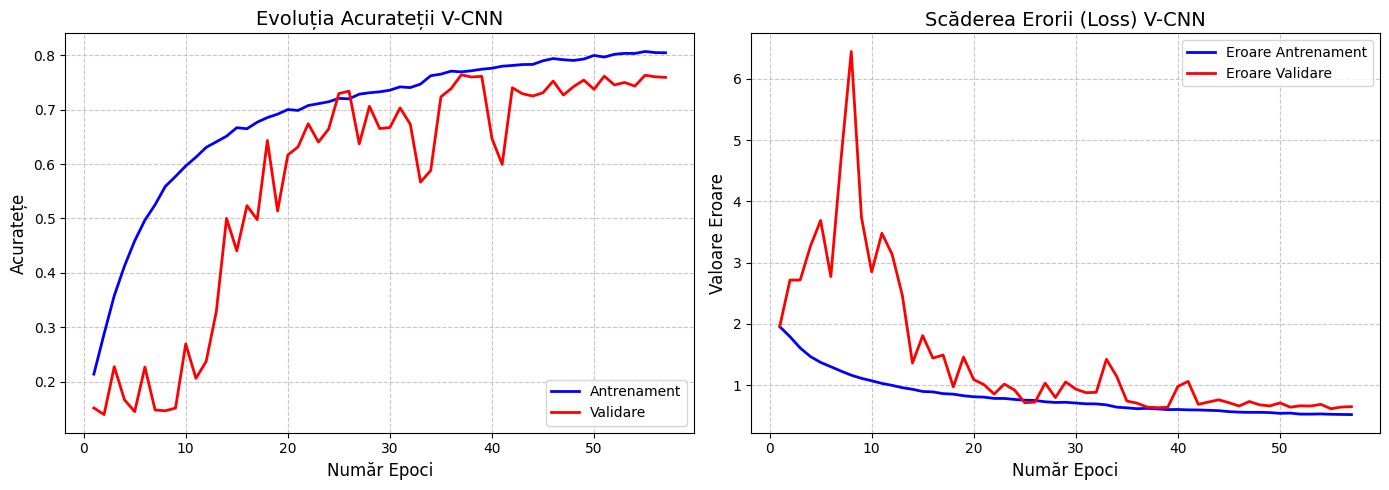

In [16]:
#graficele pentru evolutia acuratetii si scaderea erorii
#pentru setul de date de antrenament si validare
import matplotlib.pyplot as plt


acc = istoric_antrenare.history['accuracy']
val_acc = istoric_antrenare.history['val_accuracy']
loss = istoric_antrenare.history['loss']
val_loss = istoric_antrenare.history['val_loss']

epoci_rulate = range(1, len(acc) + 1)


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(epoci_rulate, acc, 'b-', linewidth=2, label='Antrenament')
plt.plot(epoci_rulate, val_acc, 'r-', linewidth=2, label='Validare')
plt.title('Evoluția Acurateții V-CNN', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Acuratețe', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
plt.plot(epoci_rulate, loss, 'b-', linewidth=2, label='Eroare Antrenament')
plt.plot(epoci_rulate, val_loss, 'r-', linewidth=2, label='Eroare Validare')
plt.title('Scăderea Erorii (Loss) V-CNN', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Valoare Eroare', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

Calculăm predicțiile pe setul de test...


I0000 00:00:1776320998.148212      12 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:6612273014232178204
E0000 00:00:1776320998.158776      12 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node sequential_6_1/batch_normalization_1/Cast/ReadVariableOp.
I0000 00:00:1776320998.201315    1352 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(5891701036843322972), session_name()


      5/Unknown 5s 29ms/step

I0000 00:00:1776321001.928739    1352 tpu_compile_op_common.cc:245] Compilation of 5891701036843322972 with session name  took 3.727389343s and succeeded
I0000 00:00:1776321001.930180    1352 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(5891701036843322972), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_distributed_6612273014232178204", property.function_library_fingerprint = 7144489933991339180, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 4, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1776321001.930192    1352 tpu_compilation_cache_interface.cc:542] After adding entry for key 58917010368433

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step


/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


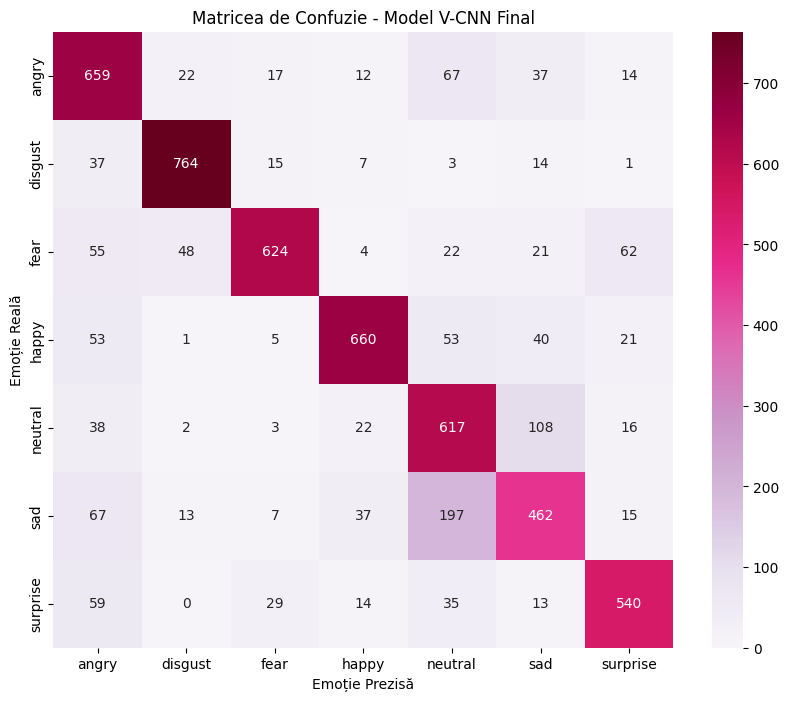


Raport de Clasificare Detaliat:

              precision    recall  f1-score   support

       angry       0.68      0.80      0.73       828
     disgust       0.90      0.91      0.90       841
        fear       0.89      0.75      0.81       836
       happy       0.87      0.79      0.83       833
     neutral       0.62      0.77      0.69       806
         sad       0.66      0.58      0.62       798
    surprise       0.81      0.78      0.79       690

    accuracy                           0.77      5632
   macro avg       0.78      0.77      0.77      5632
weighted avg       0.78      0.77      0.77      5632



In [17]:
#afisarea matricei de confuzie
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("Calculăm predicțiile pe setul de test...")

y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

etichete = clase 

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd', 
            xticklabels=etichete, yticklabels=etichete)
plt.title('Matricea de Confuzie - Model V-CNN Final')
plt.ylabel('Emoție Reală')
plt.xlabel('Emoție Prezisă')
plt.show()

print("\nRaport de Clasificare Detaliat:\n")
print(classification_report(y_true, y_pred, target_names=etichete, zero_division=0))

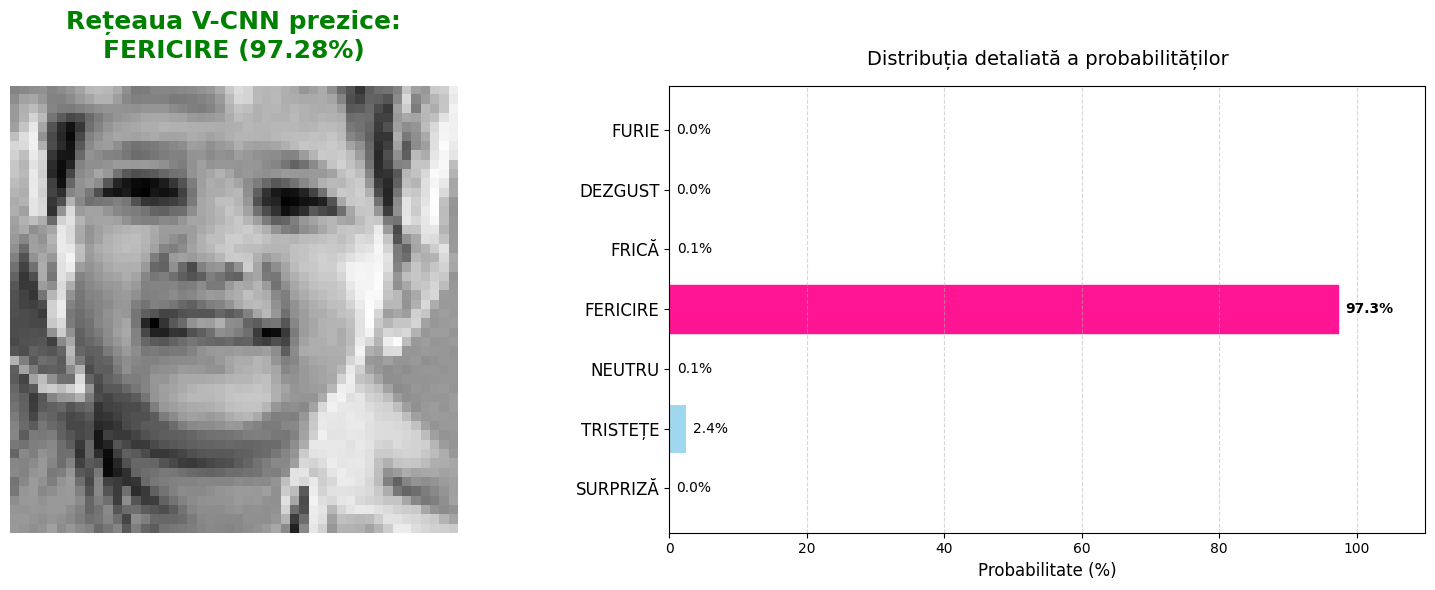

In [19]:
# === Testare Vizuală pe Imagini Individuale ===
# Funcția testeaza_cu_legenda() primește o cale de imagine și modelul antrenat,
# preprocesează imaginea identic cu pipeline-ul de antrenare (48×48, grayscale, [0,1]),
# rulează predicția și afișează un grafic cu 2 panouri:
#   - Stânga: imaginea originală + emoția prezisă (cu procent de încredere)
#   - Dreapta: distribuția probabilităților softmax pentru toate 7 clase (în română)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

def testeaza_cu_legenda(cale_imagine, model):
    etichete_en = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    
    clase_ro = {
        'angry': 'FURIE',
        'disgust': 'DEZGUST',
        'fear': 'FRICĂ',
        'happy': 'FERICIRE',
        'neutral': 'NEUTRU',
        'sad': 'TRISTEȚE',
        'surprise': 'SURPRIZĂ'
    }
    
    nume_ro_scurt = [clase_ro[e] for e in etichete_en]

    try:
        img_pt_model = image.load_img(cale_imagine, target_size=(48, 48), color_mode="grayscale")
    except Exception as e:
        print(f"Eroare la încărcarea imaginii: {e}")
        return

    img_array = image.img_to_array(img_pt_model)
    img_array = np.expand_dims(img_array, axis=0) 

    img_array = img_array / 255.0

    predictii_brute = model.predict(img_array, verbose=0)[0] 
    index_maxim = np.argmax(predictii_brute)
    
    emotie_w_en = etichete_en[index_maxim]
    emotie_w_ro = clase_ro[emotie_w_en]
    procent_w = predictii_brute[index_maxim] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    img_orig = cv2.imread(cale_imagine)
    if img_orig is None:
        print("Eroare: Nu am putut citi imaginea originală pentru afișare!")
        return
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    
    ax1.imshow(img_orig)
    ax1.axis('off') 
    
    culoare_titlu = 'green' if emotie_w_en == 'happy' else 'red' if emotie_w_en in ['angry', 'fear'] else 'darkblue'
    
    ax1.set_title(f"Rețeaua V-CNN prezice:\n{emotie_w_ro} ({procent_w:.2f}%)", 
                  fontsize=18, color=culoare_titlu, fontweight='bold', pad=20)

    y_pos = np.arange(len(nume_ro_scurt))
    procente_afisare = predictii_brute * 100
    
    bare = ax2.barh(y_pos, procente_afisare, align='center', color='skyblue', alpha=0.8)
    
    bare[index_maxim].set_color('deeppink')
    bare[index_maxim].set_alpha(1.0)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(nume_ro_scurt, fontsize=12)
    ax2.invert_yaxis() 
    ax2.set_xlabel('Probabilitate (%)', fontsize=12)
    ax2.set_title('Distribuția detaliată a probabilităților', fontsize=14, pad=15)
    
    for i, bar in enumerate(bare):
        latime = bar.get_width()
        ax2.text(latime + 1, bar.get_y() + bar.get_height()/2, 
                 f'{procente_afisare[i]:.1f}%', 
                 va='center', fontsize=10, fontweight='bold' if i == index_maxim else 'normal')

    ax2.set_xlim(0, 110) 
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

testeaza_cu_legenda('/kaggle/input/datasets/msambare/fer2013/test/happy/PrivateTest_11281040.jpg', model)

In [21]:
model.save('vcnn_best_model_fer_augmented.keras')

In [4]:
#am creeat un dataset in care am salvat toate modelele antrenate
#aici aplicam modelul nostru schimband calea acestuia la nevoie
#trebuie rulata DUPA primele 3 celule 
from tensorflow.keras.models import load_model

cale_model = '/kaggle/input/datasets/mindrocrobert/modelulmeu/vcnn_model_1aprilie.keras'
model = load_model(cale_model)

print("Modelul este acum încărcat în memorie")

Modelul este acum încărcat în memorie
